In [3]:
# import libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import sys
from os import path
from tqdm import tqdm
# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [4]:
# device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [5]:
# define path to data
# PATH = r'C:\Users\nnitzan\Desktop\spikes2lfp\session_1044594870'
PATH = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1119946360\session_1119946360'

In [6]:
# import data
lfp      = np.load(PATH + '_lfp.npy').astype(np.float32)
X        = np.load(PATH + '_spikes.npy').astype(np.float32)
df       = pd.read_csv(PATH + '_info.csv')
print(lfp.shape)
print(X.shape)
print(df.head())

(900227, 1)
(900227, 1363)
  location   probe  firing_rate  dist_from_source  cluster_id
0    VISam  probeA     0.517918       2150.256264           5
1    VISam  probeA     0.372479       2150.256264           2
2      APN  probeA     0.380829       2589.166661           0
3    VISam  probeA     0.497625       2085.977469           2
4    VISam  probeA     0.500161       2085.977469           5


In [7]:
# define constants
input_size  = X.shape[1]
hidden_size = 50  # number of units in the hidden state
num_layers  = 1  # number of vertical stacks of hidden layers (note: only the final layer gives an output)
batchsize   = 1
seqlength   = 750
bin_size    = 0.004

In [8]:
# Preprocess data
num_trials = int(lfp.shape[0] / seqlength)
X = X[:num_trials * seqlength, :]
lfp = lfp[:num_trials * seqlength, :]
X_reshaped = np.reshape(X, (num_trials, seqlength, X.shape[1]))
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength))
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)
X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])
y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1], 1)
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1], 1)
X_trainT = torch.tensor(X_train).float()
y_trainT = torch.tensor(y_train).float()
X_testT = torch.tensor(X_test).float()
y_testT = torch.tensor(y_test).float()

# remove non-tensor variables to free up memory
del X, lfp, X_reshaped, lfp_reshaped, X_train, X_test, y_train, y_test

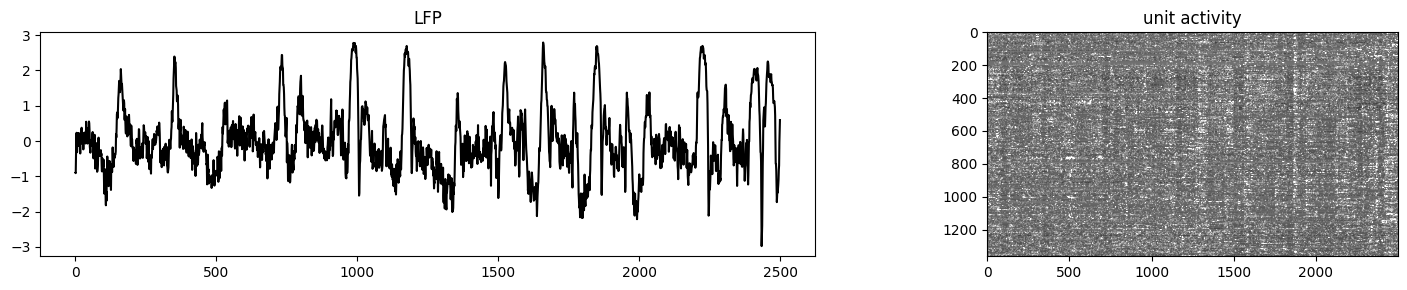

In [10]:
fig, ax = plt.subplots(1,2,figsize=(16, 3))

ax[0].plot(y_trainT.numpy()[:int(10/bin_size)],'k',label='LFP')
ax[0].set_title('LFP')

ax[1].imshow(X_trainT.numpy()[:int(10/bin_size),:].T, vmin=-1, vmax=1, cmap='gray')
ax[1].set_title('unit activity')

plt.tight_layout()
plt.show()

## create the model

In [11]:
# Define LSTM model
class LSTMnet(nn.Module):
    def __init__(self, input_size, num_hidden, num_layers, print=False):
        super().__init__()
        self.print = print
        self.input_size = input_size
        self.num_hidden = num_hidden
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, num_hidden, num_layers, dropout=0.5)
        self.out = nn.Linear(num_hidden, 1)

    def forward(self, x):
        if self.print:
            print(f'Input: {list(x.shape)}')
        y, hidden = self.lstm(x)
        if self.print:
            print(f'RNN-out: {list(y.shape)}')
            print(f'RNN-hidden: {list(hidden[0].shape)}')
            print(f'RNN-cell: {list(hidden[1].shape)}')
        o = self.out(y)
        if self.print:
            print(f'Output: {list(o.shape)}')
        return o

In [12]:
# create an LSTM instance
net = LSTMnet(input_size,hidden_size,num_layers, print = True)

# test the model with some data
somedata = X_trainT[:seqlength,:].view(seqlength,1,input_size)

y  = net(somedata)

lossfun = nn.MSELoss()
lossfun(torch.squeeze(y), torch.squeeze(y_trainT[:seqlength]))

Input: [750, 1, 1363]
RNN-out: [750, 1, 50]
RNN-hidden: [1, 1, 50]
RNN-cell: [1, 1, 50]
Output: [750, 1, 1]


c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


tensor(0.5510, grad_fn=<MseLossBackward0>)

## a function to train the model 

In [13]:
def train(model_inp, numepochs = 15):
    lossfun = nn.MSELoss()
    N = y_train.shape[0]
    model_inp.to(device)
    optimizer = torch.optim.Adam(model_inp.parameters(),lr=.001, weight_decay=0.001)
    # initialize losses
    losses = np.zeros(numepochs)

    for epochi in range(numepochs):
      # loop over data segments
      seglosses = []
    
      for timei in range(0, N - seqlength, seqlength):
        # grab a snippet of data
        X = X_trainT[timei:timei+seqlength,:].view(seqlength,1,input_size).to(device)
        y = y_trainT[timei:timei+seqlength].view(seqlength,1).to(device)
        # forward pass and loss
        yHat = model_inp(X)
        loss = lossfun(torch.squeeze(y), torch.squeeze(yHat))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        seglosses.append(loss.item())
      # average losses from this epoch
      losses[epochi] = np.mean(seglosses)
      msg = f'Finished epoch {epochi+1}/{numepochs}'
      sys.stdout.write('\r' + msg)
    return losses

In [14]:
def train_load_save_model(model_obj, model_path, force_train=False):
    if (path.isfile(model_path)) & (not force_train):
        # load model
        print('Loading pre-trained model from: {}'.format(model_path))
        model_obj.load_state_dict(torch.load(model_path))
        losses = None
        return losses
    else:    
        # train model
        losses = train(model_obj)
        print('Finished training the model. Saving the model to the path: {}'.format(model_path))
        torch.save(model_obj.state_dict(), model_path)
        return losses

In [15]:
model = LSTMnet(input_size,hidden_size,num_layers)

SAVED_MODEL_PATH = PATH + '_trained_lstm.pt'
losses = train_load_save_model(model, SAVED_MODEL_PATH)
model = model.to(device)

Loading pre-trained model from: Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1119946360\session_1119946360_trained_lstm.pt


C:\Users\SB13FLPC018\AppData\Local\Temp\ipykernel_53064\2120602031.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_obj.load_state_dict(torch.load(model_path))


Text(0.5, 1.0, 'Model loss')

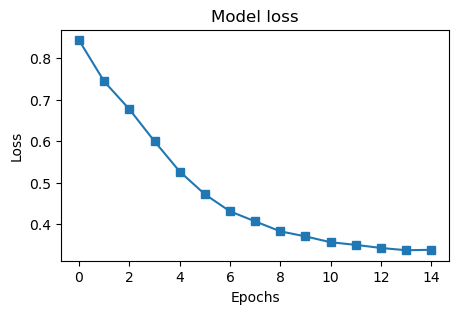

In [160]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

ax.plot(losses,'s-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss')


In [16]:
# Function to evaluate the model
def evaluate(model, X_data):
    model.eval()
    N = X_data.shape[0] - np.mod(X_data.shape[0], seqlength)
    y_hat = np.zeros(X_data.shape[0])
    with torch.no_grad():
        for timei in range(0, N, seqlength):
            X = X_data[timei:timei+seqlength, :].view(seqlength, 1, input_size).to(device)
            yy = model(X)
            y_hat[timei:timei+seqlength] = np.squeeze(yy.cpu().numpy())
    return y_hat

## test the network

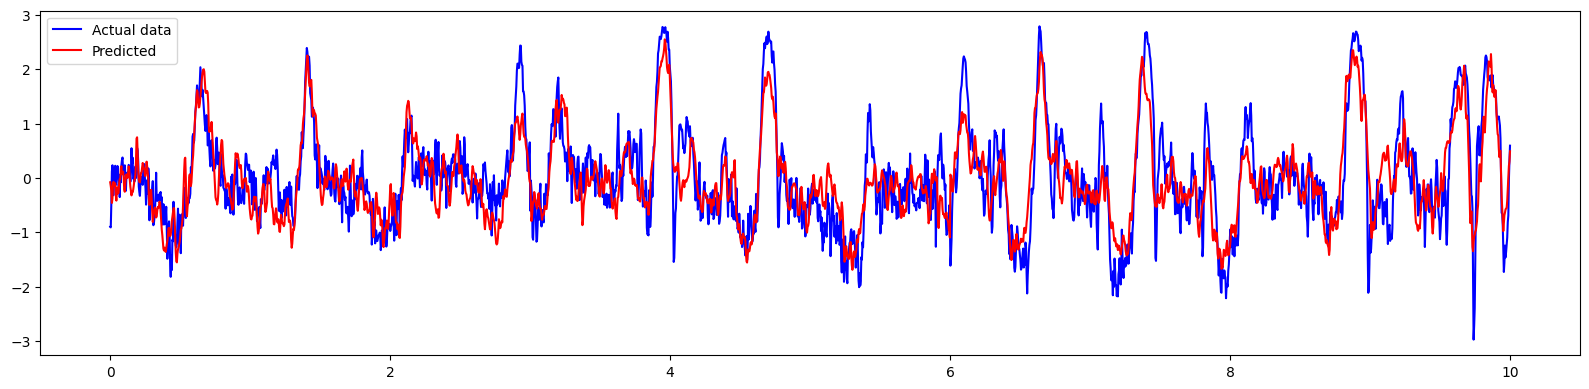

In [17]:
y_hat_train = evaluate(model, X_trainT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(np.linspace(0,10,int(10/bin_size)) ,y_trainT.numpy()[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_train[:int(10/bin_size),4],'b',label='Actual data')

ax.plot(np.linspace(0,10,int(10/bin_size)) ,y_hat_train[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()


## Test on new data

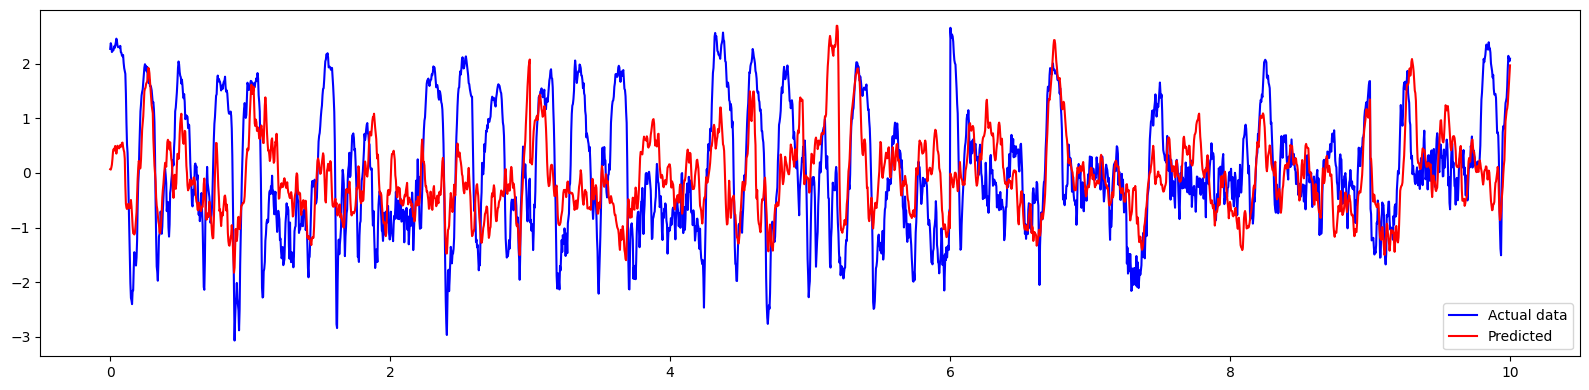

In [18]:
y_hat_test = evaluate(model, X_testT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(np.linspace(0,10,int(10/bin_size)) ,y_testT.numpy()[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(np.linspace(0,10,int(10/bin_size)) ,y_hat_test[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [164]:
# print mse for test data 
print(f'MSE test data: {lossfun(torch.squeeze(y_testT), torch.squeeze(torch.tensor(y_hat_test)))}')

MSE test data: 0.9552894858319464


## test on passive data

In [19]:
X_pas    = np.load(PATH +'_spikes_pas.npy').astype(np.float32)
pas_lfp      = np.load(PATH +'_pas_lfp.npy').astype(np.float32)
X_pasT   = torch.tensor( X_pas ).float()
pas_lfpT = torch.tensor( pas_lfp ).float()

del X_pas, pas_lfp

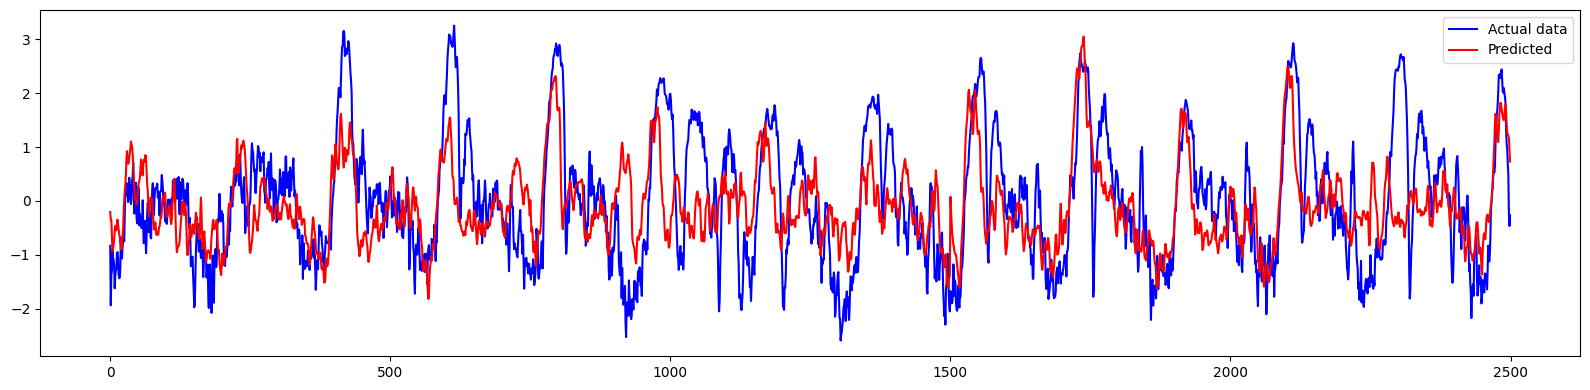

In [21]:
y_hat_pas= evaluate(model, X_pasT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(pas_lfpT.numpy()[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(y_hat_pas[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

## test on spontaneous data

In [167]:
X_spont    = np.load(PATH +'_spikes_spont.npy').astype(np.float32)
spont      = np.load(PATH +'_spont_lfp.npy').astype(np.float32)
X_spontT   = torch.tensor( X_spont ).float()
spont_lfpT = torch.tensor( spont ).float()

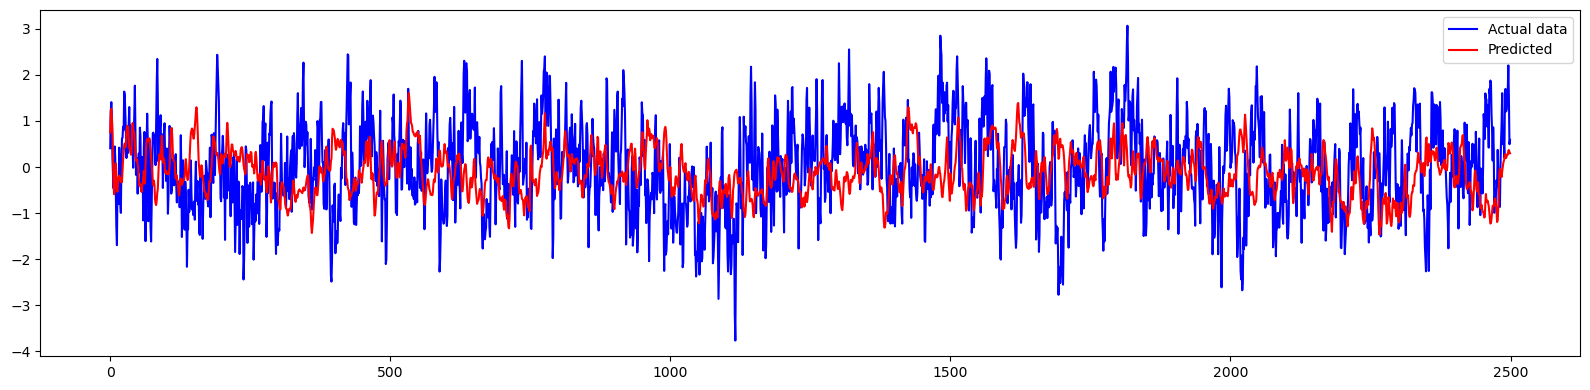

In [168]:
y_hat_spont = evaluate(model, X_spontT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(spont[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(y_hat_spont[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [169]:
# print mse for test data 
print(f'MSE test data: {lossfun(torch.squeeze(spont_lfpT), torch.squeeze(torch.tensor(y_hat_spont)))}')

MSE test data: 1.2845598908321425


## test on gabor stimulations data

In [170]:
X_gabor    = np.load(PATH +'_spikes_gabor.npy').astype(np.float32)
gabor      = np.load(PATH +'_gabor_lfp.npy').astype(np.float32)
X_gaborT   = torch.tensor( X_gabor ).float()
gabor_lfpT = torch.tensor( gabor ).float()

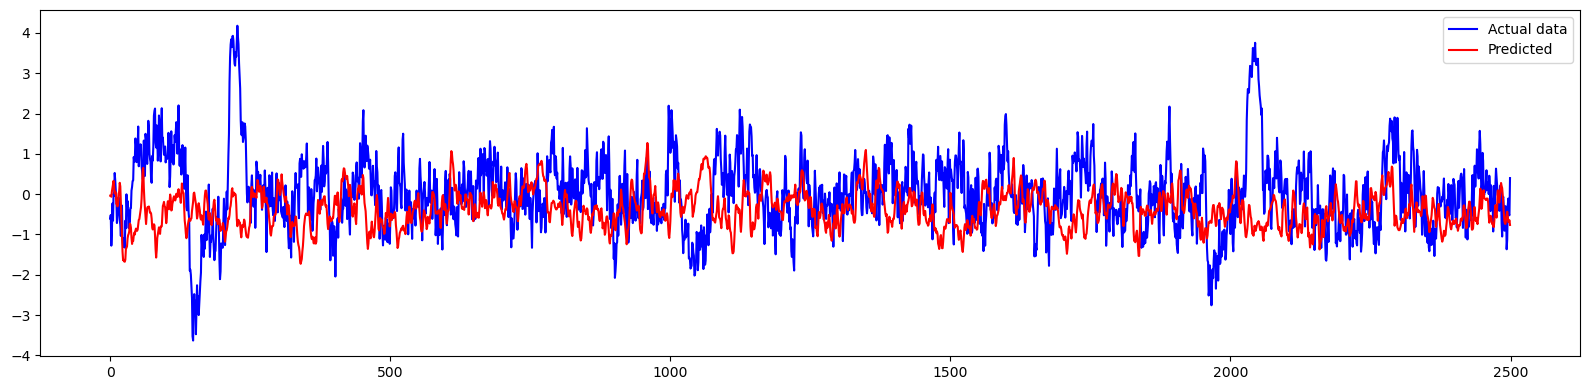

In [171]:
y_hat_gabor = evaluate(model, X_gaborT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(gabor[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(y_hat_gabor[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

## attribution analysis using captum

In [24]:
model.train()
X_testT = X_testT.to(device)

ATTRIBUTIONS_PATH = PATH + '_lstm_attr.np'

if path.isfile(ATTRIBUTIONS_PATH):
  print('Loading saved attributions from: {}'.format(ATTRIBUTIONS_PATH))
  attributions = np.load(ATTRIBUTIONS_PATH)
else:
  print('running attribution analysis')
  # Initialize the attribution algorithm with the model
  integrated_gradients = IntegratedGradients(model)
  attributions = []
  for i in tqdm(range(0,X_testT.shape[0],300)):
    attributions.append(integrated_gradients.attribute(X_testT[i:i+300,:].contiguous(),  target=0,  n_steps=200))
  attributions = torch.cat(attributions)
  attributions = attributions.cpu().detach().numpy()
  np.save(ATTRIBUTIONS_PATH, attributions, 'allow_pickle=True')

running attribution analysis


100%|██████████| 600/600 [18:30<00:00,  1.85s/it]


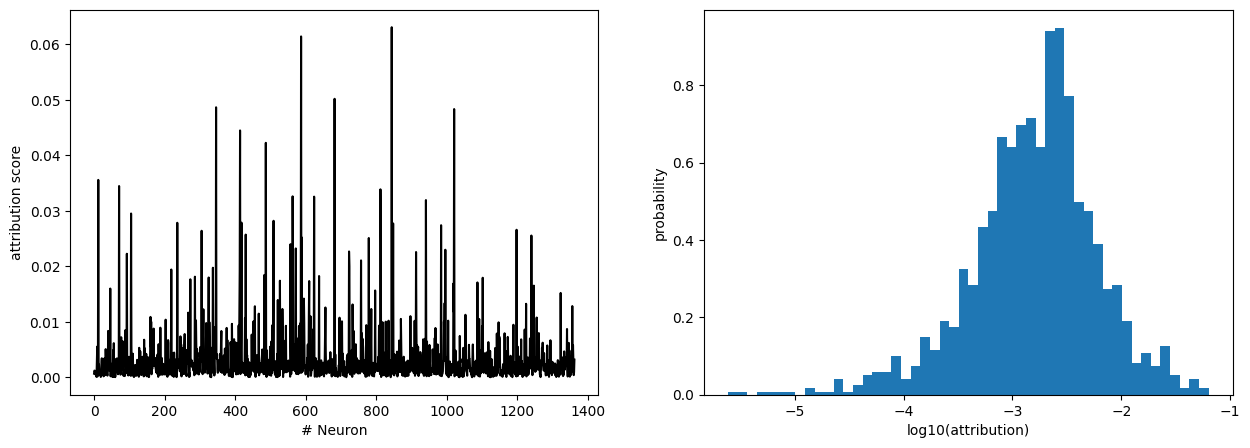

In [31]:
mean_attr_over_time = np.mean(attributions,0)
df['attribution'] = np.abs(mean_attr_over_time)

fig,ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(np.arange(0,X_testT.shape[1],1), np.abs(mean_attr_over_time) , 'k')
ax[0].set_xlabel('# Neuron')
ax[0].set_ylabel('attribution score')

ax[1].hist(np.log10(np.abs(mean_attr_over_time)), bins = 50, density=True)
ax[1].set_xlabel('log10(attribution)')
ax[1].set_ylabel('probability')

plt.show()

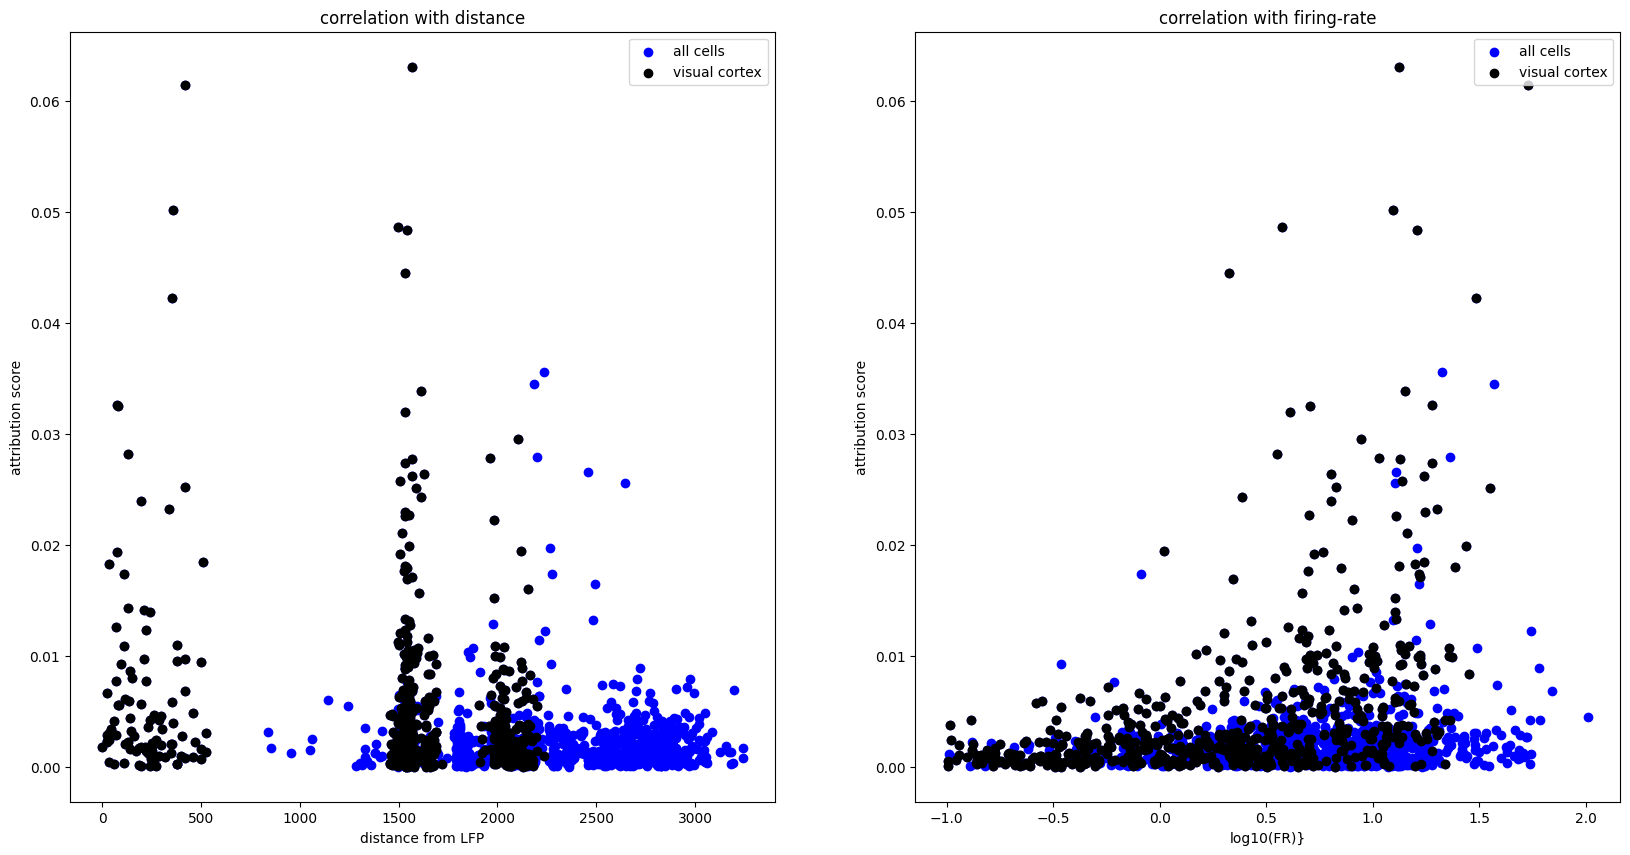

In [33]:
fig, ax = plt.subplots(1,2, figsize=(20,10))

ax[0].scatter(df.dist_from_source, df.attribution,color='blue' )
ax[0].scatter(df.dist_from_source[df.location.str.contains('VIS')], df.attribution[df.location.str.contains('VIS')], color ='k')
ax[0].legend(['all cells', 'visual cortex'])
ax[0].set_title('correlation with distance')
ax[0].set_xlabel('distance from LFP')
ax[0].set_ylabel('attribution score')


ax[1].scatter(np.log10(df.firing_rate), df.attribution, color='blue')
ax[1].scatter(np.log10(df.firing_rate[df.location.str.contains('VIS')]), df.attribution[df.location.str.contains('VIS')], color ='k')
ax[1].legend(['all cells', 'visual cortex'])
ax[1].set_title('correlation with firing-rate')
ax[1].set_xlabel('log10(FR)}')
ax[1].set_ylabel('attribution score')
plt.show()

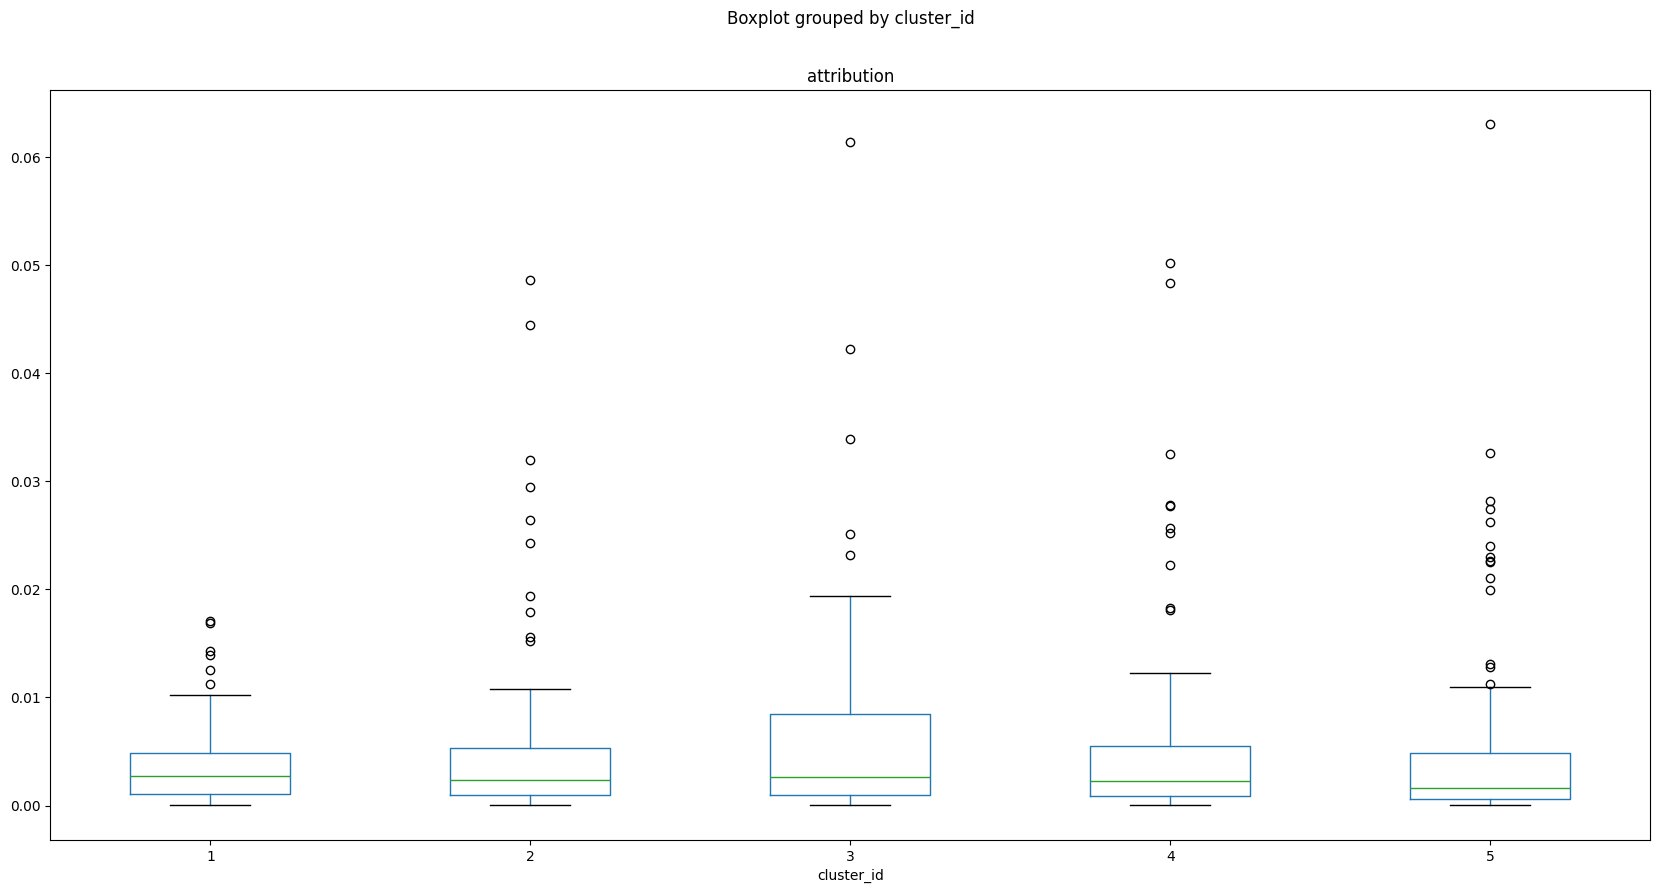

In [34]:
fig, ax = plt.subplots(1,1, figsize=(20,10))

# Create the boxplot
df.boxplot(column='attribution', by='cluster_id', ax=ax, grid=False)
ax.set_xlim([1.5, 6.5])
plt.show()

In [35]:
df[['location', 'attribution', 'firing_rate', 'dist_from_source']].groupby('location').median().sort_values('attribution', ascending=False)

,attribution,firing_rate,dist_from_source
location,,,
TH,0.004639,11.363557,2615.114374
LP,0.003538,9.031627,2208.192926
VISp,0.003007,2.680762,223.125525
VISl,0.002902,3.137443,1546.213439
VISal,0.002676,2.201157,1541.373414
POL,0.002543,11.641241,2700.484401
VISpm,0.002453,3.264727,1559.434834
LGd,0.002114,11.093499,2541.869194
APN,0.002091,10.204791,2589.166661


location                   VISl
probe                    probeD
firing_rate           13.326127
dist_from_source    1566.708652
cluster_id                    5
attribution             0.06311
Name: 844, dtype: object


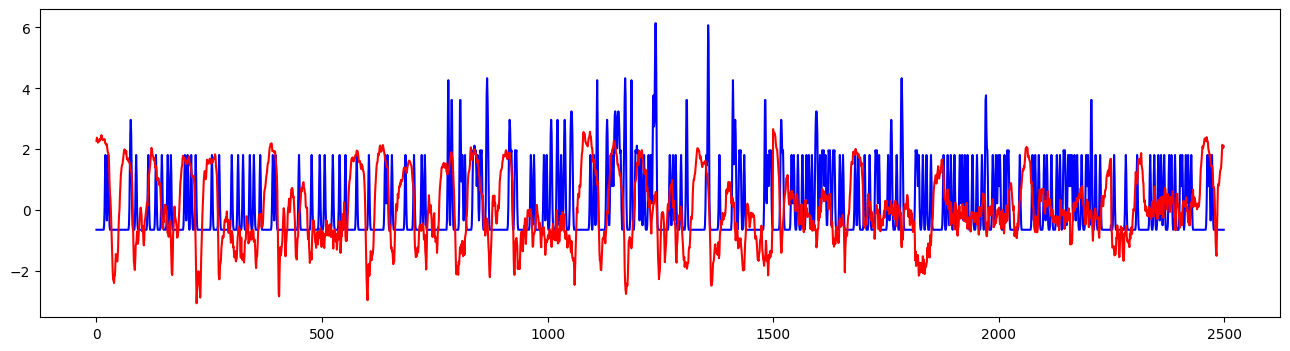

In [38]:
# find the neuron with the highest attribution 
sidx = np.argsort(mean_attr_over_time)[::-1]
print(df.iloc[sidx[0]])
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(X_testT.cpu().numpy()[:int(10/bin_size),sidx[0]],'b',label='best predictor neuron')
ax.plot(y_testT.cpu().numpy()[:int(10/bin_size)],'r',label='LFP')
# ax.legend()